In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tells jupyter notebook to display the plots in the notebook itself
%matplotlib inline
import seaborn as sns

df = pd.read_csv("../diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv")

In [3]:
# drop the columns that are not useful for our analysis

# encounter_id and patient_nbr are unique identifiers for each encounter and patient, respectively. 
# ML algorithms do not need these identifiers to learn patterns in the data, and they can actually introduce noise and lead to overfitting.
df.drop(columns=["encounter_id", "patient_nbr", "payer_code", "medical_specialty", "weight"], inplace=True)

In [4]:
# write me a function that will search through rows of df. For an inputted feature, if there is a missing value or question mark, delete that row.
def drop_missing_values(df, feature):
    df = df[df[feature] != "?"]
    df = df.dropna(subset=[feature])
    return df

df = drop_missing_values(df, "race")
df = drop_missing_values(df, "gender")
df = drop_missing_values(df, "diag_1")
df = drop_missing_values(df, "diag_2")
df = drop_missing_values(df, "diag_3")

In [5]:
# now for each feature currently in df, give me the number of missing data
for column in df.columns:
    missing_count = df[column].isna().sum() + (df[column] == "?").sum()
    print(f"Column: {column}, Missing Values: {missing_count}")

Column: race, Missing Values: 0
Column: gender, Missing Values: 0
Column: age, Missing Values: 0
Column: admission_type_id, Missing Values: 0
Column: discharge_disposition_id, Missing Values: 0
Column: admission_source_id, Missing Values: 0
Column: time_in_hospital, Missing Values: 0
Column: num_lab_procedures, Missing Values: 0
Column: num_procedures, Missing Values: 0
Column: num_medications, Missing Values: 0
Column: number_outpatient, Missing Values: 0
Column: number_emergency, Missing Values: 0
Column: number_inpatient, Missing Values: 0
Column: diag_1, Missing Values: 0
Column: diag_2, Missing Values: 0
Column: diag_3, Missing Values: 0
Column: number_diagnoses, Missing Values: 0
Column: max_glu_serum, Missing Values: 92845
Column: A1Cresult, Missing Values: 81860
Column: metformin, Missing Values: 0
Column: repaglinide, Missing Values: 0
Column: nateglinide, Missing Values: 0
Column: chlorpropamide, Missing Values: 0
Column: glimepiride, Missing Values: 0
Column: acetohexamide, 

In [6]:
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [7]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [8]:
# write me a function that will do one-hot encoding on a single feature and return the new dataframe with the one-hot encoded feature
def one_hot_encode(df, feature):
    if feature in df.columns:
        one_hot = pd.get_dummies(df[feature], prefix=feature)
        df = df.drop(feature, axis=1)
        df = df.join(one_hot)
    elif not any(col.startswith(f"{feature}_") for col in df.columns):
        raise KeyError(f"Feature '{feature}' not found in dataframe.")
    return df

df = one_hot_encode(df, "race")
df = one_hot_encode(df, "gender")
df = one_hot_encode(df, "age")
df = one_hot_encode(df, "admission_type_id")
df = one_hot_encode(df, "discharge_disposition_id")
df = one_hot_encode(df, "admission_source_id")
df = one_hot_encode(df, "diag_1")
df = one_hot_encode(df, "diag_2")
df = one_hot_encode(df, "diag_3")
df = one_hot_encode(df, "max_glu_serum")
df = one_hot_encode(df, "A1Cresult")

# give me a function that will do one-hot encoding on the diabetes medications and return the new dataframe with the one-hot encoded features
def one_hot_encode_diabetes_medications(df):
    diabetes_medications = [
    'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed'
    ]
    
    for feature in diabetes_medications:
        df = one_hot_encode(df, feature)
    
    return df

df = one_hot_encode_diabetes_medications(df)
df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,race_AfricanAmerican,...,glipizide-metformin_Steady,glimepiride-pioglitazone_No,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_No,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
1,3,59,0,18,0,0,0,9,>30,False,...,False,True,False,True,True,False,True,False,False,True
2,2,11,5,13,2,0,1,6,NO,True,...,False,True,False,True,True,False,False,True,False,True
3,2,44,1,16,0,0,0,7,NO,False,...,False,True,False,True,True,False,True,False,False,True
4,1,51,0,8,0,0,0,5,NO,False,...,False,True,False,True,True,False,True,False,False,True
5,3,31,6,16,0,0,0,9,>30,False,...,False,True,False,True,True,False,False,True,False,True


In [9]:
# run logistic regression on the data to predict readmission
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
X = df.drop("readmitted", axis=1)
y = df["readmitted"]
# i want to the feature of the exact value causing the value error

# make this into train validation test split instead of just train test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [10]:
# standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_val_scaled)

print("Validation Set Performance:")
print(classification_report(y_val, y_pred, labels=logreg.classes_))
print(confusion_matrix(y_val, y_pred, labels=logreg.classes_))

# multiclass ROC-AUC for <30, >30, and NO/none
y_pred_proba = logreg.predict_proba(X_val_scaled)
roc_auc = roc_auc_score(
    y_val,
    y_pred_proba,
    multi_class="ovr",
    labels=logreg.classes_
)

print(f"Multiclass ROC-AUC Score: {roc_auc:.4f}")
print("Classes:", logreg.classes_)

Validation Set Performance:
              precision    recall  f1-score   support

         <30       0.32      0.05      0.09      1633
         >30       0.50      0.38      0.43      5234
          NO       0.61      0.82      0.70      7841

    accuracy                           0.58     14708
   macro avg       0.48      0.42      0.41     14708
weighted avg       0.54      0.58      0.54     14708

[[  88  622  923]
 [  95 2000 3139]
 [  96 1350 6395]]
Multiclass ROC-AUC Score: 0.6647
Classes: ['<30' '>30' 'NO']


In [15]:
# i want to see the predicted probabilities for the first 5 samples in the validation set
print("Predicted probabilities for the first 5 samples in the validation set:")
print(y_pred_proba[:5])
# label them
for i in range(5):
    print(f"Sample {i+1}:")
    for j, class_label in enumerate(logreg.classes_):
        print(f"  Probability of being '{class_label}': {y_pred_proba[i][j]:.4f}")
# give me the actual results for the first 5 samples in the validation set
print("\nActual readmission status for the first 5 samples in the validation set:")
for i in range(5):
    print(f"Sample {i+1}: Actual readmission status: '{y_val.iloc[i]}'")

Predicted probabilities for the first 5 samples in the validation set:
[[0.08869827 0.36871416 0.54258757]
 [0.10208583 0.3212771  0.57663707]
 [0.13814689 0.34291707 0.51893604]
 [0.23633676 0.47543107 0.28823216]
 [0.2154446  0.48054764 0.30400776]]
Sample 1:
  Probability of being '<30': 0.0887
  Probability of being '>30': 0.3687
  Probability of being 'NO': 0.5426
Sample 2:
  Probability of being '<30': 0.1021
  Probability of being '>30': 0.3213
  Probability of being 'NO': 0.5766
Sample 3:
  Probability of being '<30': 0.1381
  Probability of being '>30': 0.3429
  Probability of being 'NO': 0.5189
Sample 4:
  Probability of being '<30': 0.2363
  Probability of being '>30': 0.4754
  Probability of being 'NO': 0.2882
Sample 5:
  Probability of being '<30': 0.2154
  Probability of being '>30': 0.4805
  Probability of being 'NO': 0.3040

Actual readmission status for the first 5 samples in the validation set:
Sample 1: Actual readmission status: '>30'
Sample 2: Actual readmission st

Top 20 Most Important Features (Logistic Regression):
                          feature  importance
44    discharge_disposition_id_11    0.372550
6                number_inpatient    0.238541
781                    diag_1_V55    0.134369
462                    diag_1_566    0.125257
54    discharge_disposition_id_22    0.111019
1295                   diag_2_782    0.109722
1147                   diag_2_553    0.107923
732                    diag_1_945    0.107511
512                    diag_1_620    0.105784
455                    diag_1_556    0.101876
535                    diag_1_654    0.100262
1050                   diag_2_429    0.099014
1091                   diag_2_478    0.096396
811                    diag_2_155    0.094545
16                     age_[0-10)    0.093313
1887                   diag_3_537    0.092493
1087                   diag_2_473    0.091134
1319                   diag_2_807    0.089310
934                    diag_2_289    0.086339
1186                   dia

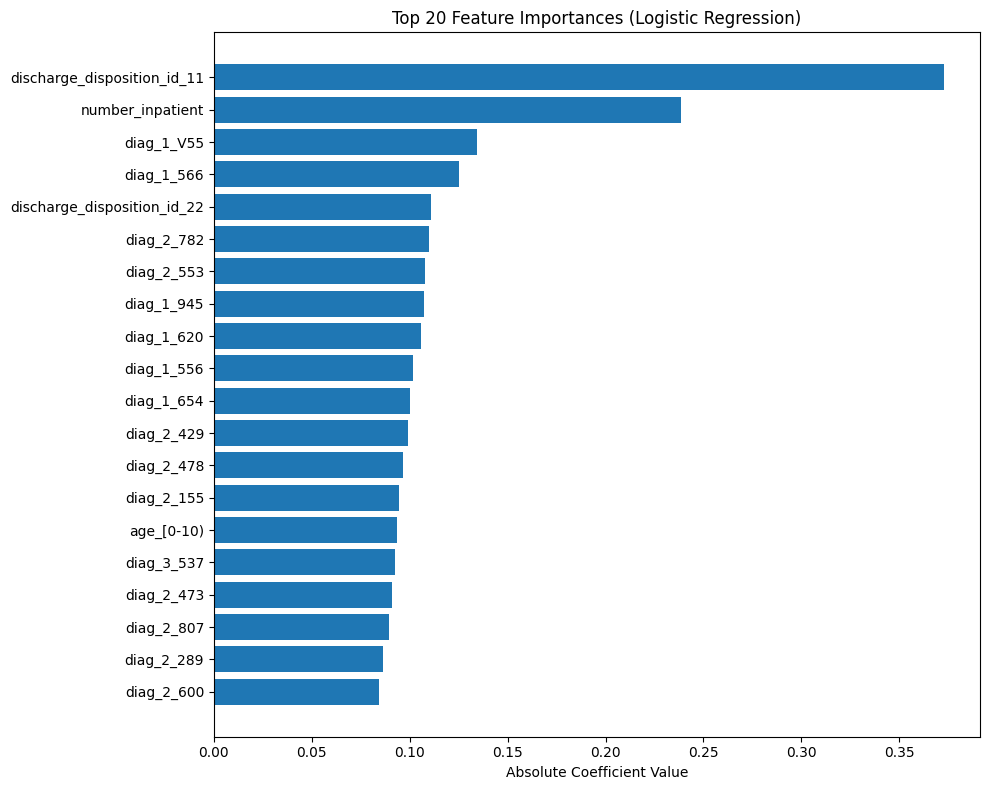

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names
feature_names = X_train.columns

# Get absolute values of coefficients (importance)
importance = np.abs(logreg.coef_[0])

# Create a DataFrame for easy viewing
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print("Top 20 Most Important Features (Logistic Regression):")
print(feature_importance.head(20))

# Plot top 20 features
top20 = feature_importance.head(20)
plt.figure(figsize=(10, 8))
plt.barh(top20['feature'][::-1], top20['importance'][::-1])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Feature Importances (Logistic Regression)')
plt.tight_layout()
plt.show()
